<a href="https://colab.research.google.com/github/thecodemaster152/rice-type-classification/blob/main/Rice_type_classification_using_pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [65]:
!pip install opendatasets --quiet
import opendatasets as od
od.download("https://www.kaggle.com/datasets/mssmartypants/rice-type-classification")

Skipping, found downloaded files in "./rice-type-classification" (use force=True to force download)


In [66]:
import torch
import torch.nn as nn
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader
from torchsummary import summary
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [67]:
data_df = pd.read_csv("/content/rice-type-classification/riceClassification.csv")

In [68]:
data_df.head()

,id,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
0,1,4537,92.229316,64.012769,0.719916,4677,76.004525,0.657536,273.085,0.764510,1.440796,1
1,2,2872,74.691881,51.400454,0.725553,3015,60.471018,0.713009,208.317,0.831658,1.453137,1
2,3,3048,76.293164,52.043491,0.731211,3132,62.296341,0.759153,210.012,0.868434,1.465950,1
3,4,3073,77.033628,51.928487,0.738639,3157,62.551300,0.783529,210.657,0.870203,1.483456,1
4,5,3693,85.124785,56.374021,0.749282,3802,68.571668,0.769375,230.332,0.874743,1.510000,1


In [69]:
data_df.describe()

,id,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
count,18185.000000,18185.000000,18185.000000,18185.000000,18185.000000,18185.000000,18185.000000,18185.000000,18185.000000,18185.000000,18185.000000,18185.000000
mean,9093.000000,7036.492989,151.680754,59.807851,0.915406,7225.817872,94.132952,0.616653,351.606949,0.707998,2.599081,0.549079
std,5249.701658,1467.197150,12.376402,10.061653,0.030575,1502.006571,9.906250,0.104389,29.500620,0.067310,0.434836,0.497599
min,1.000000,2522.000000,74.133114,34.409894,0.676647,2579.000000,56.666658,0.383239,197.015000,0.174590,1.358128,0.000000
25%,4547.000000,5962.000000,145.675910,51.393151,0.891617,6125.000000,87.126656,0.538530,333.990000,0.650962,2.208527,0.000000
50%,9093.000000,6660.000000,153.883750,55.724288,0.923259,6843.000000,92.085696,0.601194,353.088000,0.701941,2.602966,1.000000
75%,13639.000000,8423.000000,160.056214,70.156593,0.941372,8645.000000,103.559146,0.695664,373.003000,0.769280,2.964101,1.000000
max,18185.000000,10210.000000,183.211434,82.550762,0.966774,11008.000000,114.016559,0.886573,508.511000,0.904748,3.911845,1.000000


In [70]:
data_df.dropna(inplace= True)
data_df = data_df.iloc[:,1:]

In [71]:
data_df.head()

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
0,4537,92.229316,64.012769,0.719916,4677,76.004525,0.657536,273.085,0.764510,1.440796,1
1,2872,74.691881,51.400454,0.725553,3015,60.471018,0.713009,208.317,0.831658,1.453137,1
2,3048,76.293164,52.043491,0.731211,3132,62.296341,0.759153,210.012,0.868434,1.465950,1
3,3073,77.033628,51.928487,0.738639,3157,62.551300,0.783529,210.657,0.870203,1.483456,1
4,3693,85.124785,56.374021,0.749282,3802,68.571668,0.769375,230.332,0.874743,1.510000,1


In [72]:
from itertools import groupby
data_df['Class'].value_counts()

,count
Class,
1,9985
0,8200


In [73]:
original_df = data_df.copy()
for column in data_df.columns:
  data_df[column] = data_df[column]/data_df[column].abs().max()

data_df.head()

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
0,0.444368,0.503404,0.775435,0.744658,0.424873,0.666610,0.741661,0.537029,0.844997,0.368316,1.0
1,0.281293,0.407681,0.622653,0.750489,0.273892,0.530370,0.804230,0.409661,0.919215,0.371471,1.0
2,0.298531,0.416421,0.630442,0.756341,0.284520,0.546380,0.856278,0.412994,0.959862,0.374747,1.0
3,0.300979,0.420463,0.629049,0.764024,0.286791,0.548616,0.883772,0.414262,0.961818,0.379222,1.0
4,0.361704,0.464626,0.682901,0.775033,0.345385,0.601418,0.867808,0.452954,0.966836,0.386007,1.0


In [74]:
X = np.array(data_df.iloc[:, :-1])
y = np.array(data_df.iloc[:, -1])

In [75]:
X,y

(array([[0.44436827, 0.50340371, 0.77543522, ..., 0.5370287 , 0.844997  ,
         0.36831616],
        [0.28129285, 0.40768133, 0.62265269, ..., 0.40966075, 0.91921498,
         0.37147093],
        [0.29853085, 0.41642141, 0.63044229, ..., 0.41299402, 0.95986205,
         0.37474651],
        ...,
        [0.62340842, 0.84480035, 0.64091576, ..., 0.67304935, 0.75472018,
         0.74783024],
        [0.58374143, 0.8263563 , 0.62355087, ..., 0.67524793, 0.70210346,
         0.75187447],
        [0.60078355, 0.83554818, 0.62495614, ..., 0.6658912 , 0.74305096,
         0.7585284 ]]),
 array([1., 1., 1., ..., 0., 0., 0.]))

In [76]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3 )

In [77]:
X_val, X_test, y_val, y_test = train_test_split(X_test, y_test, test_size = 0.5 )

In [78]:
X_train.shape, X_test.shape, X_val.shape

((12729, 10), (2728, 10), (2728, 10))

In [79]:
class dataset(Dataset):
  def __init__(self,X,y):
    self.X = torch.tensor(X , dtype =torch.float32).to(device)
    self.Y = torch.tensor(y , dtype =torch.float32).to(device)

  def __len__(self):
      return len(self.X)

  def __getitem__(self, idx):
      return self.X[idx], self.Y[idx]

In [90]:
training_data = dataset(X_train , y_train)
testing_data = dataset(X_test , y_test)
validation_data = dataset(X_val , y_val)

In [92]:
train_dataloader = DataLoader(training_data, batch_size=32, shuffle=True)
test_dataloader = DataLoader(testing_data, batch_size=32, shuffle=True)
val_dataloader = DataLoader(validation_data, batch_size=32, shuffle=True)

In [93]:
train_dataloader

In [94]:
for X,y in train_dataloader:
  print(X)
  print("++++++++++++++++++++++++++")
  print(y)
  break


tensor([[0.9408, 0.9249, 0.8833, 0.9337, 0.9045, 0.9700, 0.7423, 0.7846, 0.8382,
         0.5941],
        [0.7308, 0.7885, 0.8135, 0.9158, 0.7052, 0.8548, 0.7798, 0.6923, 0.8363,
         0.5499],
        [0.6373, 0.8157, 0.6827, 0.9580, 0.6096, 0.7983, 0.7332, 0.6732, 0.7712,
         0.6779],
        [0.5458, 0.7652, 0.6291, 0.9608, 0.5190, 0.7388, 0.6855, 0.6335, 0.7458,
         0.6900],
        [0.6002, 0.8701, 0.5994, 0.9833, 0.5720, 0.7747, 0.6776, 0.6895, 0.6924,
         0.8235],
        [0.7849, 0.8274, 0.8323, 0.9220, 0.7477, 0.8860, 0.7036, 0.7146, 0.8429,
         0.5640],
        [0.8311, 0.8618, 0.8428, 0.9285, 0.8008, 0.9117, 0.6599, 0.7512, 0.8078,
         0.5802],
        [0.7862, 0.8443, 0.8168, 0.9309, 0.7552, 0.8867, 0.7687, 0.7276, 0.8143,
         0.5865],
        [0.5467, 0.7900, 0.6107, 0.9696, 0.5215, 0.7394, 0.5415, 0.6398, 0.7324,
         0.7339],
        [0.7597, 0.8316, 0.7948, 0.9335, 0.7202, 0.8716, 0.6626, 0.7014, 0.8470,
         0.5936],
        [0

In [95]:
HIDDEN_NEURONS = 10
class MyModel(nn.Module):
  def __init__(self):
    super(MyModel,self).__init__()

    self.input_layer = nn.Linear(X.shape[1], HIDDEN_NEURONS)

    self.linear = nn.Linear(HIDDEN_NEURONS, 1)

    self.sigmoid = nn.Sigmoid()

  def forward(self, x):
    x = self.input_layer(x)
    x = self.linear(x)
    x = self.sigmoid(x)
    return x


model = MyModel().to(device)

In [96]:
summary(model, (1, X.shape[1]))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                [-1, 1, 10]             110
            Linear-2                 [-1, 1, 1]              11
           Sigmoid-3                 [-1, 1, 1]               0
Total params: 121
Trainable params: 121
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00
----------------------------------------------------------------


In [97]:
criterion = nn.BCELoss()
optimizer = Adam(model.parameters(), lr = 0.001)

Training the model

In [109]:
total_loss_train_plot = []
total_loss_val_plot = []
total_acc_train_plot = []
total_acc_val_plot = []

epochs = 10

for epoch in range(epochs):
  total_acc_train = 0
  total_loss_train = 0
  total_acc_val = 0
  total_loss_val = 0

  for data in train_dataloader:
    inputs , labels = data

    prediction = model(inputs).squeeze(1)

    batch_loss = criterion(prediction, labels)

    total_loss_train += batch_loss.item()

    acc = ((prediction).round() == labels).sum().item()

    total_acc_tranin += acc


    ##backpropogation
    batch_loss.backward()
    optimizer.step()
    optimizer.zero_grad()

  with torch.no_grad():                    ##thid means use the pytorch model but dont change the weights
    for data in val_dataloader:
      inputs , labels = data

      prediction = model(inputs).squeeze(1)
      batch_loss = criterion(prediction, labels)

      total_loss_val += batch_loss.item()
      acc = ((prediction).round() == labels).sum().item()
      total_acc_val += acc                ##you see in the validation we didnt do any backpropogation bcause we dont want to chnage the weights

  total_loss_train_plot.append(round(total_loss_train/1000,4))
  total_loss_val_plot.append(round(total_loss_val/1000,4))

  total_acc_train_plot.append(round(total_acc_train/(training_data.__len__())*100, 4))
  total_acc_val_plot.append(round(total_acc_val/(validation_data.__len__())*100, 4))

  print(f'''Epoch no. {epoch + 1} Train Loss: {total_loss_train/1000:.4f} Train Accuracy: {(total_acc_train/(training_data.__len__())*100):.4f} Validation Loss: {total_loss_val/1000:.4f} Validation Accuracy: {(total_acc_val/(validation_data.__len__())*100):.4f}''')
  print("="*50)



Epoch no. 1 Train Loss: 0.0157 Train Accuracy: 0.0000 Validation Loss: 0.0033 Validation Accuracy: 98.4604
Epoch no. 2 Train Loss: 0.0156 Train Accuracy: 0.0000 Validation Loss: 0.0042 Validation Accuracy: 98.4238
Epoch no. 3 Train Loss: 0.0156 Train Accuracy: 0.0000 Validation Loss: 0.0035 Validation Accuracy: 98.4604
Epoch no. 4 Train Loss: 0.0156 Train Accuracy: 0.0000 Validation Loss: 0.0035 Validation Accuracy: 98.4238
Epoch no. 5 Train Loss: 0.0156 Train Accuracy: 0.0000 Validation Loss: 0.0034 Validation Accuracy: 98.4971
Epoch no. 6 Train Loss: 0.0157 Train Accuracy: 0.0000 Validation Loss: 0.0034 Validation Accuracy: 98.5337
Epoch no. 7 Train Loss: 0.0157 Train Accuracy: 0.0000 Validation Loss: 0.0033 Validation Accuracy: 98.4971
Epoch no. 8 Train Loss: 0.0156 Train Accuracy: 0.0000 Validation Loss: 0.0033 Validation Accuracy: 98.5704
Epoch no. 9 Train Loss: 0.0155 Train Accuracy: 0.0000 Validation Loss: 0.0033 Validation Accuracy: 98.4971
Epoch no. 10 Train Loss: 0.0157 Train

In [110]:
with torch.no_grad():
  total_loss_test = 0
  total_acc_test = 0
  for data in testing_data:
    inputs , labels = data

    prediction = model(inputs).squeeze()

    batch_loss_test = criterion(prediction , labels)
    total_loss_test += batch_loss_test.item()

    total_acc_test += ((prediction).round() == labels).sum().item()

  print("accuracy" , round(total_acc_test/(testing_data.__len__())*100, 4))


accuracy 98.607


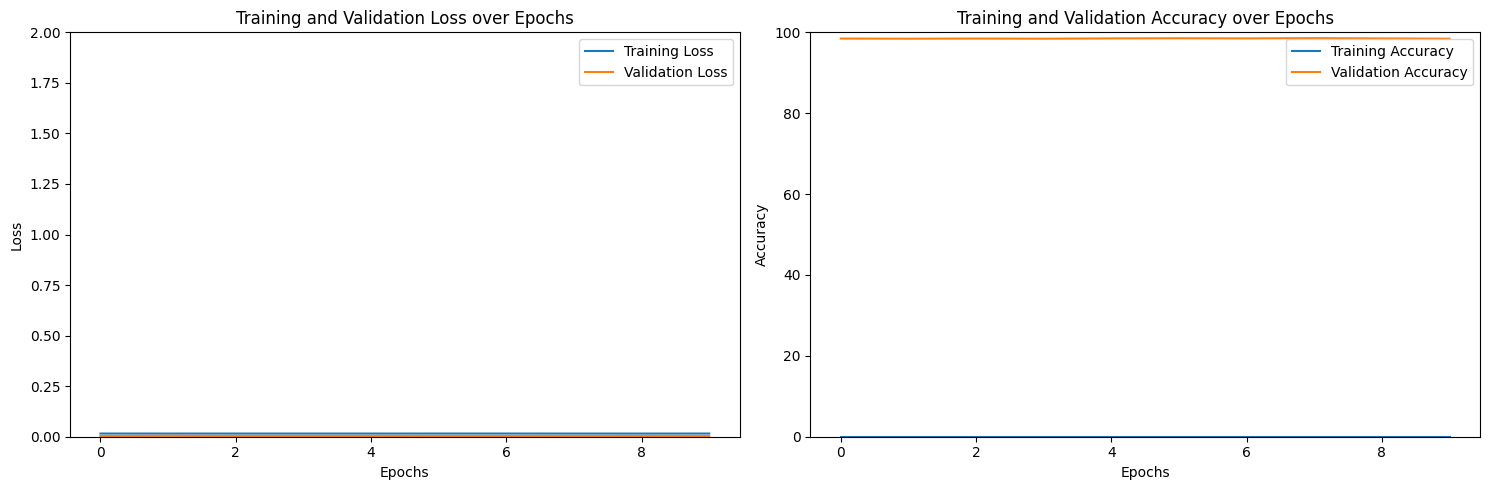

In [111]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))

axs[0].plot(total_loss_train_plot, label='Training Loss')
axs[0].plot(total_loss_val_plot, label='Validation Loss')
axs[0].set_title('Training and Validation Loss over Epochs')
axs[0].set_xlabel('Epochs')
axs[0].set_ylabel('Loss')
axs[0].set_ylim([0, 2])
axs[0].legend()

axs[1].plot(total_acc_train_plot, label='Training Accuracy')
axs[1].plot(total_acc_val_plot, label='Validation Accuracy')
axs[1].set_title('Training and Validation Accuracy over Epochs')
axs[1].set_xlabel('Epochs')
axs[1].set_ylabel('Accuracy')
axs[1].set_ylim([0, 100])
axs[1].legend()

plt.tight_layout()

plt.show()